## TC 5033
### Word Embeddings
### Team # 73

* A00959089 - Marcelo Ismael López Verdugo
* A01796847 - Pedro Cuauhtemoc Marquez Correo
* A01625357 - Edson Alejandro Lozano García
* A01796999 - Christian Gustavo Martínez Ramírez

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy
<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project: 
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)
|



#### Import libraries

In [40]:
# Import libraries
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
import pickle
plt.style.use('ggplot')

#### Load file

There's a possibility of using one of the three available GloVE files.  The number (50d, 100d and 200d) is the amount of dimensions, the higher the dimension is the higher the capacity of creating semantic conections.  Also having high dimensionality means that the algorithm is going to be heavier due extra sofistications.

In [49]:
# PATH = '/media/pepe/DataUbuntu/Databases/glove_embeddings/glove.6B.200d.txt'
PATH = 'glove_embeddings/glove.6B.200d.txt'
emb_dim = 200

In [114]:
# Create dictionary with embeddings
def create_emb_dictionary(path, save_path=None):
    embeddings_dict = {}

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = np.array(values[1:], dtype=np.float32)
            embeddings_dict[word] = vector

    #Serialize the dictionary
    if save_path is not None:
        with open(save_path, 'wb') as f:
            pickle.dump(embeddings_dict, f)

    return embeddings_dict


In [115]:
# Create dictionary
embeddings_dict = create_emb_dictionary(PATH,save_path='embeddings_dict_200D.pkl')

In [116]:
# Serialize
with open('embeddings_dict_200D.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)

# Deserialize
with open('embeddings_dict_200D.pkl', 'rb') as f:
     embeddings_dict = pickle.load(f)

After the creation of the pickle file we can open and use faster the dictionary.  This is a way to use the pre-trained data for this implementation.

#### See some embeddings

In [118]:
# Show some
def show_n_first_words(path, n_words):
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                print(line.split(), len(line.split()[1:]))
                if i>=n_words: break

In [119]:
show_n_first_words(PATH, 5)

['the', '-0.071549', '0.093459', '0.023738', '-0.090339', '0.056123', '0.32547', '-0.39796', '-0.092139', '0.061181', '-0.1895', '0.13061', '0.14349', '0.011479', '0.38158', '0.5403', '-0.14088', '0.24315', '0.23036', '-0.55339', '0.048154', '0.45662', '3.2338', '0.020199', '0.049019', '-0.014132', '0.076017', '-0.11527', '0.2006', '-0.077657', '0.24328', '0.16368', '-0.34118', '-0.06607', '0.10152', '0.038232', '-0.17668', '-0.88153', '-0.33895', '-0.035481', '-0.55095', '-0.016899', '-0.43982', '0.039004', '0.40447', '-0.2588', '0.64594', '0.26641', '0.28009', '-0.024625', '0.63302', '-0.317', '0.10271', '0.30886', '0.097792', '-0.38227', '0.086552', '0.047075', '0.23511', '-0.32127', '-0.28538', '0.1667', '-0.0049707', '-0.62714', '-0.24904', '0.29713', '0.14379', '-0.12325', '-0.058178', '-0.001029', '-0.082126', '0.36935', '-0.00058442', '0.34286', '0.28426', '-0.068599', '0.65747', '-0.029087', '0.16184', '0.073672', '-0.30343', '0.095733', '-0.5286', '-0.22898', '0.064079', '0.0

### Plot some embeddings

To plot a high dimensionality word association is required the usage of a transform.  For this project we are using PCA and t-SNE.

In [112]:
def plot_embeddings(words2show, embeddings_dict, reducer_class=PCA):

    # Obtener embeddings
    valid_words = [w for w in words2show if w in embeddings_dict]
    word_embeddings = np.array([embeddings_dict[w] for w in valid_words])

    if len(valid_words) == 0:
        print("No valid words found in embeddings.")
        return

    # Reducción de dimensionalidad
    if reducer_class == TSNE:
        reducer = TSNE(n_components=2, random_state=42, perplexity=min(30, len(valid_words)-1))
        explained=None
    else:
        reducer = reducer_class(n_components=2)
        pca_explained=PCA(n_components=2)
        explained = pca_explained.fit(word_embeddings).explained_variance_ratio_ * 100

    reduced = reducer.fit_transform(word_embeddings)

    # Plot
    plt.figure(figsize=(8,8))
    plt.scatter(reduced[:,0], reduced[:,1])

    for i, word in enumerate(valid_words):
        plt.annotate(word, (reduced[i,0], reduced[i,1]))

    plt.title(f"{reducer_class.__name__} visualization of embeddings")
    plt.title(f"{reducer_class.__name__} visualization of embeddings (Explained variance: {explained.sum():.2f}%)" if explained is not None else f"{reducer_class.__name__} visualization of embeddings")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    plt.show()

#### Testing words

In [79]:
words= ['burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips', 
            'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
            'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
            'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
            'school', 'work', 'university', 'highschool']


#### Plotting using PCA
When using PCA we can rotate to eigenvector and use first 2 PCA.  Since this transformation is focused in the use of variance we can compute the amount of variance explained with those 2 components.  
Is very important to acknoledge that this 2D representation is showing only part of the explained variance and not the full dictionary capacity with all of its PCA.  A 26.53% was found to be the explained variance in this 2 PCAs, meaning that this representation can be showing clusters not very well.

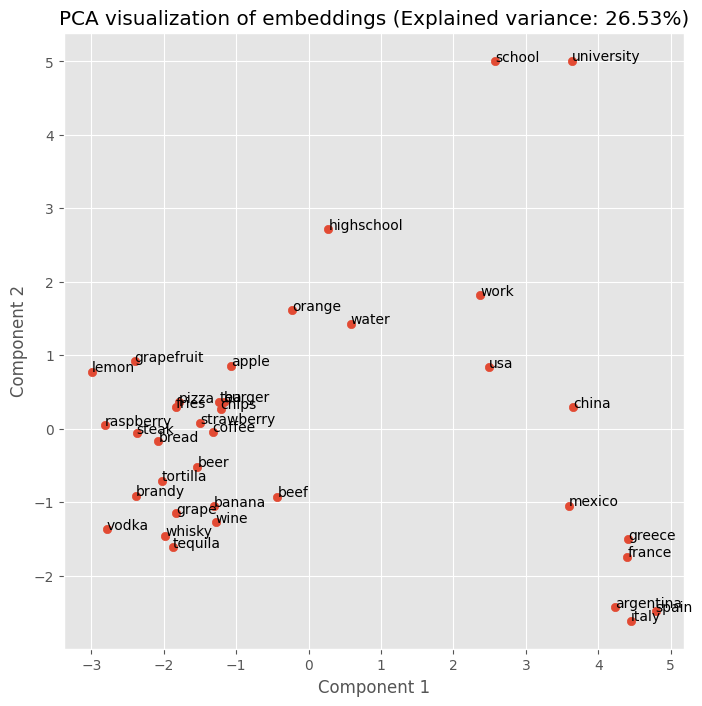

In [ ]:
# Plotting with PCA
plot_embeddings(words, embeddings_dict, PCA)

#### t-SNE
This representation is build with the goal of showing distance between the words allowing that a 2D representation to be better clustered visually.  In this case the countries are very nearby for example.  
Also this representation doesn't show all the dimensiones being used into the algorithms

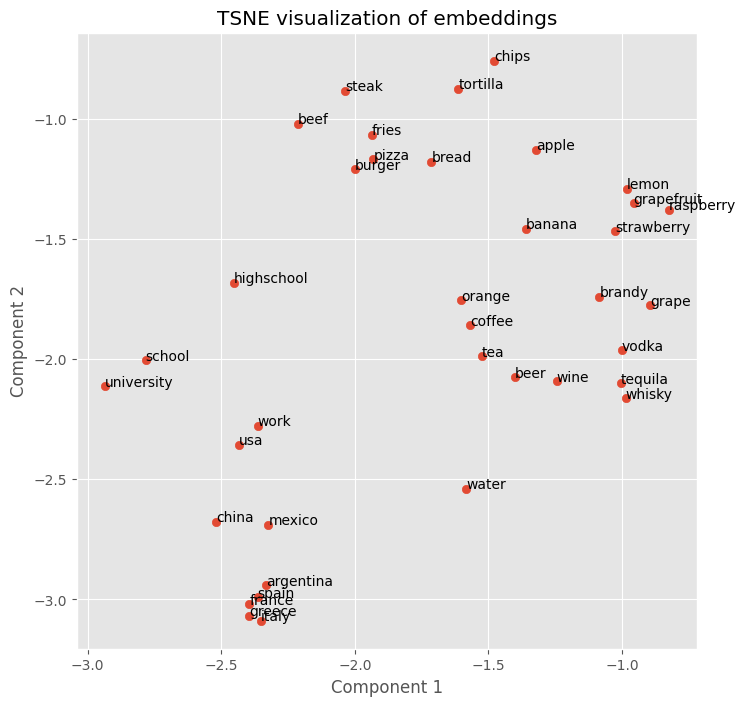

In [109]:
# t-SNE dimensionality reduction for visualization
embeddings = plot_embeddings(words, embeddings_dict, TSNE)

### Let us compute analogies
This analogy algorithm is using the vectors in all of its dimensions orthonormally.  This means that numeric associations in high dimensionality can allows us to travel inside the multidimensional space and find a nearby word.  For analogy the logic followed is a substraction and the adding of a new "concept".  
__If you substract the "man" from the "king", and add a "woman", you're replacing the man with the woman in the concept of king... so you get "queen"__  
Mathematically:  
analogy= king - man + woman   

For academic porpuses we programmed a "torch" algorithm and we found that computing speed is 100x faster using "numpy"

In [121]:
# analogy using toch
def analogy_torch(word1, word2, word3, embeddings_dict):
    if word1 not in embeddings_dict or word2 not in embeddings_dict or word3 not in embeddings_dict:
        print("One of the words is not in the embeddings dictionary.")
        return None

    vec1 = torch.tensor(embeddings_dict[word1])
    vec2 = torch.tensor(embeddings_dict[word2])
    vec3 = torch.tensor(embeddings_dict[word3])

    # Compute the analogy vector
    analogy_vec = vec2 - vec1 + vec3

    # Find the most similar word to the analogy vector
    max_sim = -float('inf')
    best_word = None

    for word, embedding in embeddings_dict.items():
        if word in [word1, word2, word3]:
            continue  # Skip the input words

        embedding_vec = torch.tensor(embedding)
        sim = F.cosine_similarity(analogy_vec.unsqueeze(0), embedding_vec.unsqueeze(0)).item()

        if sim > max_sim:
            max_sim = sim
            best_word = word

    return best_word

In [122]:
# analogy using numpy
def analogy(word1, word2, word3, embeddings_dict):

    if word1 not in embeddings_dict or word2 not in embeddings_dict or word3 not in embeddings_dict:
        print("One of the words is not in the embeddings dictionary.")
        return None

    vec1 = embeddings_dict[word1]
    vec2 = embeddings_dict[word2]
    vec3 = embeddings_dict[word3]

    # analogy vector
    analogy_vec = vec2 - vec1 + vec3

    best_word = None
    max_sim = -np.inf

    analogy_norm = np.linalg.norm(analogy_vec)

    for word, vec in embeddings_dict.items():

        if word in (word1, word2, word3):
            continue

        sim = np.dot(analogy_vec, vec) / (analogy_norm * np.linalg.norm(vec))

        if sim > max_sim:
            max_sim = sim
            best_word = word

    return best_word


In [123]:
analogy('man', 'king', 'woman', embeddings_dict)

'queen'

In [124]:
analogy_torch('man', 'king', 'woman', embeddings_dict)

'queen'

torch 8.2 seconds  
numpy 0.8 seconds

#### Finding the most similar
Same as computing analogies is possible to find top X of concepts or words in the high dimensionally space.  The cosine similarity is used to find the distance vector between each of the words, and sorting them we can plot similar concepts.  

We tested with torch and numpy to show the performance between them

In [100]:
# most similar
def find_most_similar_torch(word, embeddings_dict, top_n=10):
    if word not in embeddings_dict:
        print(f"{word} is not in the embeddings dictionary.")
        return None

    target_vec = torch.tensor(embeddings_dict[word])
    similarities = []

    for other_word, embedding in embeddings_dict.items():
        if other_word == word:
            continue  # Skip the input word

        other_vec = torch.tensor(embedding)
        sim = F.cosine_similarity(target_vec.unsqueeze(0), other_vec.unsqueeze(0)).item()
        similarities.append((other_word, sim))

    # Sort by similarity and return the top N
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]


In [101]:
# most similar
def find_most_similar(word, embeddings_dict, top_n=10):

    if word not in embeddings_dict:
        print(f"{word} is not in the embeddings dictionary.")
        return None

    target_vec = embeddings_dict[word]
    target_norm = np.linalg.norm(target_vec)

    similarities = []

    for other_word, vec in embeddings_dict.items():

        if other_word == word:
            continue

        sim = np.dot(target_vec, vec) / (target_norm * np.linalg.norm(vec))
        similarities.append((other_word, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:top_n]


In [102]:
most_similar = find_most_similar('mexico', embeddings_dict)

In [125]:
most_similar_torch = find_most_similar_torch('mexico', embeddings_dict)

numpy 0.9 seconds  
toch  8.7 seconds

In [103]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]}')

1 ---> mexican
2 ---> venezuela
3 ---> colombia
4 ---> peru
5 ---> guatemala
6 ---> argentina
7 ---> brazil
8 ---> chile
9 ---> bolivia
10 ---> america
